In [8]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
# Set figure parameters
sc.set_figure_params(dpi=100, vector_friendly=True) 
# vector_friendly=True rasterizes large objects (such as dots in a scatterplot as pixels).
# More at https://scanpy.readthedocs.io/en/stable/generated/scanpy.set_figure_params.html

In [9]:
## read processed Xenium data
data = sc.read("xenium_4donors_processed.h5ad")

In [14]:
## We'll use nichePCA for detecting domains

In [12]:
# Install nichePCA
pip install --no-deps nichepca

Note: you may need to restart the kernel to use updated packages.


In [15]:
import nichepca as npc

ℹ️ nichePCA contains multiple options of data processing, here we don't do any preprocessing as data is already preprocessed. For availabel nichePCA options, check [Customization](https://github.com/imsb-uke/nichepca?tab=readme-ov-file#customization).

ℹ️ nichePCA computes PCA on aggregated gene expression with function .wf.nichepca. It includes following parameters:

1. knn: Number of nearest neighbors to consider for one cell
2. pipeline: ["log1p", "agg", "pca"], for example, does log-normalization, aggregation of gene expression of k-nearest neighbors of a cell, pca on aggregated expression. pipeline=["norm", "log1p", "pca", "agg"] sums the total cell count to a common value first.
3. sample_key: batch key to remove the effect of. Since nichePCA computes PCA on the aggregated expression, process is identical to normal PCA, and hence, Harmony or any other batch correction algorithm can be used. Same advantage is with MENDER.
4. obs_key: a column name form .obs. It could be cell type label for example. In this case nichePCA will use these labels for aggregation. It could perform better in case of batch effects, but will lose information about different cell subsets.

Under the hood, first neighborhood graph is computed, pipeline is run and if a smaple_key is provided, Harmony is run.

In [22]:
%%time
npc.wf.nichepca(data, knn=25, sample_key="Slide_ID", pipeline=["agg", "pca"])

/data/projects/robin/xenium_multiview/xenium_cgn_1/lib/python3.11/site-packages/nichepca/utils/_helper.py:80: UserWarning: adata.X might not contain raw counts!
adata.X.max() = 2.259216785430908, adata.X.sum() = 2317141.0
  warn(


  0%|          | 0/1 [00:00<?, ?it/s]

----------- Graph Stats -----------
Number of nodes: 198585
Number of edges: 5737291
Average in-degree: 28.890857696533203
Average out-degree: 28.890857696533203
Contains self-loops: True
Is undirected: True
Running pipeline: agg->pca


2025-09-21 09:12:32,281 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-21 09:12:47,627 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-21 09:12:48,635 - harmonypy - INFO - Iteration 1 of 50
2025-09-21 09:14:12,748 - harmonypy - INFO - Iteration 2 of 50
2025-09-21 09:15:33,875 - harmonypy - INFO - Iteration 3 of 50
2025-09-21 09:16:57,040 - harmonypy - INFO - Iteration 4 of 50
2025-09-21 09:17:47,512 - harmonypy - INFO - Iteration 5 of 50
2025-09-21 09:18:12,496 - harmonypy - INFO - Converged after 5 iterations


CPU times: user 1h 11min 16s, sys: 1h 18min 28s, total: 2h 29min 45s
Wall time: 5min 46s


ℹ️ nichePCA stores the computed embedding in X_npca.

In [25]:
## Run Leiden clustering

sc.pp.neighbors(data, use_rep="X_npca")
sc.tl.leiden(data, resolution=0.25, key_added="nichePCA_cluster")

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


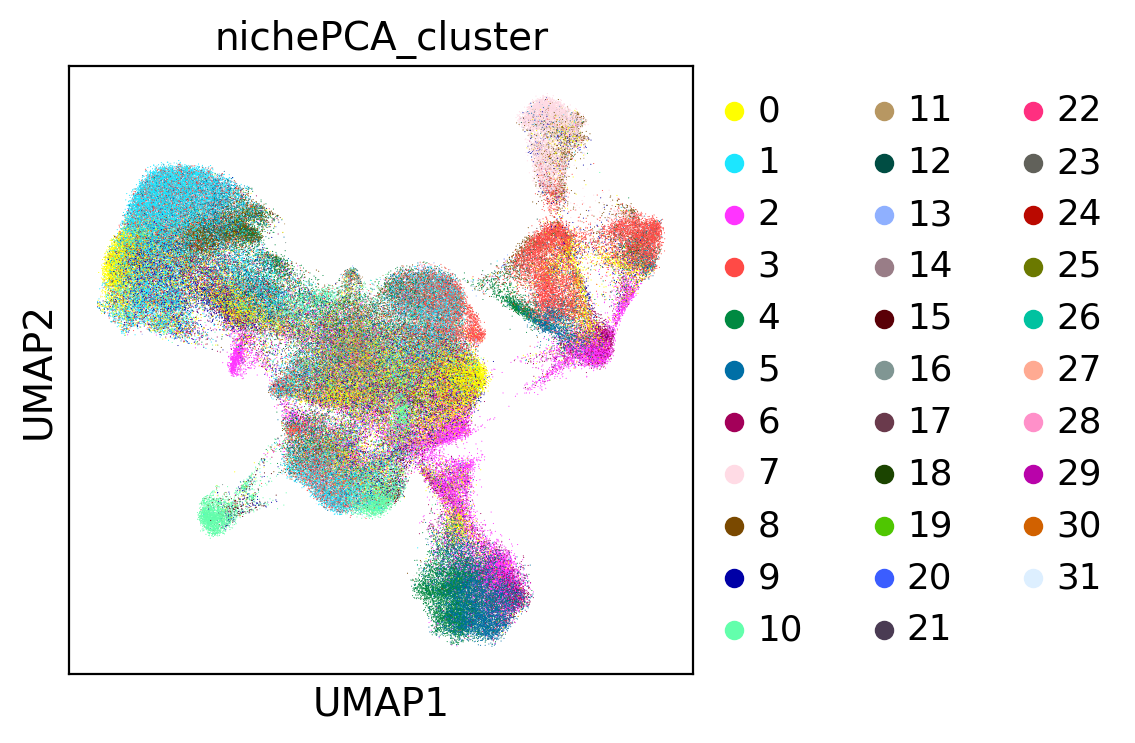

In [26]:
sc.pl.umap(data, color="nichePCA_cluster")

In [27]:
## Save nichePCA clustered data
data.write("xenium_4donors_processed.h5ad")
# Since no previous value is modified, we're just overwriting the file

/data/projects/robin/xenium_multiview/xenium_cgn_1/lib/python3.11/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


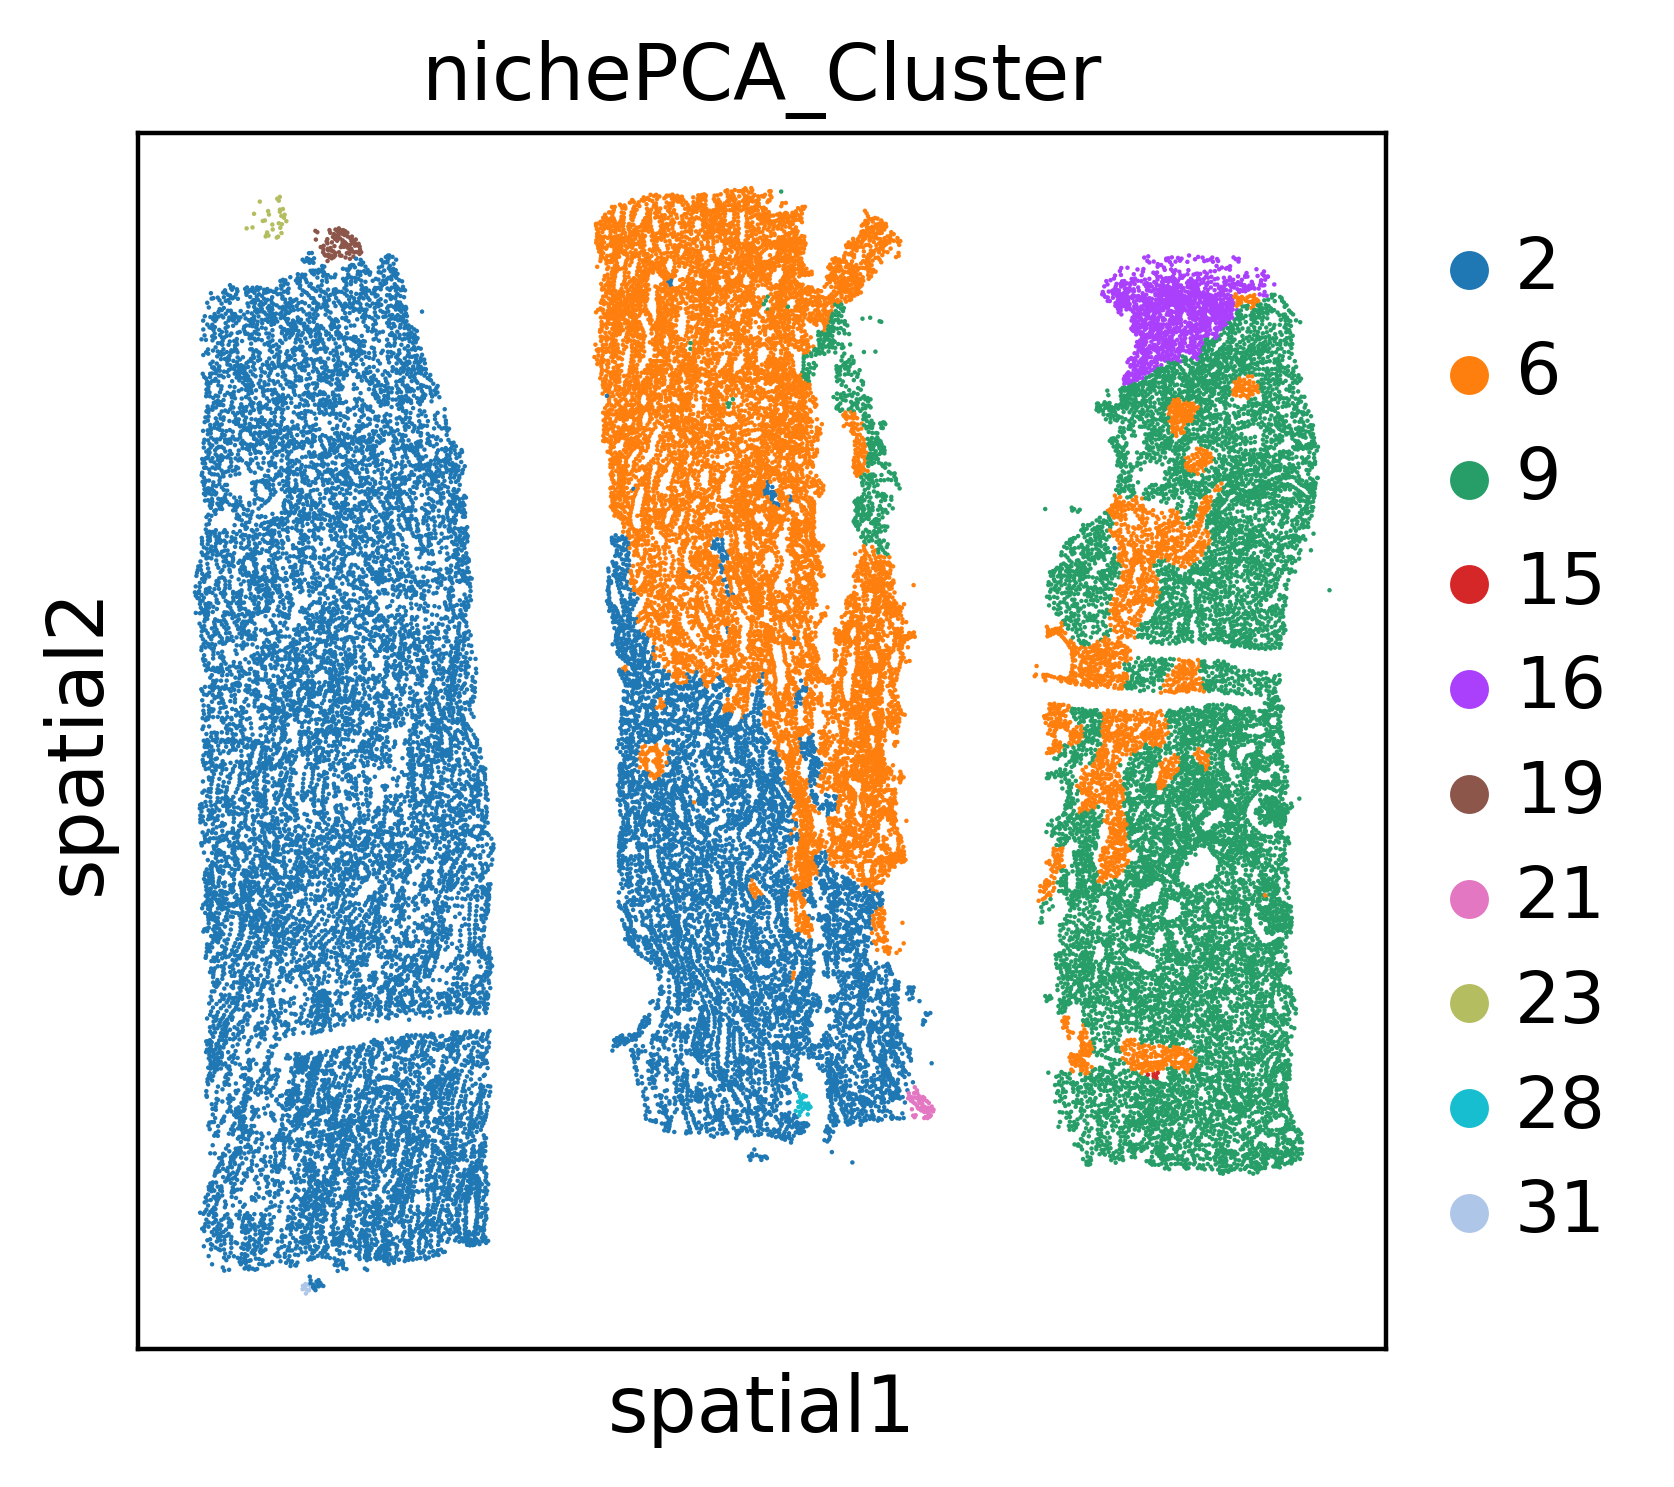

/data/projects/robin/xenium_multiview/xenium_cgn_1/lib/python3.11/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


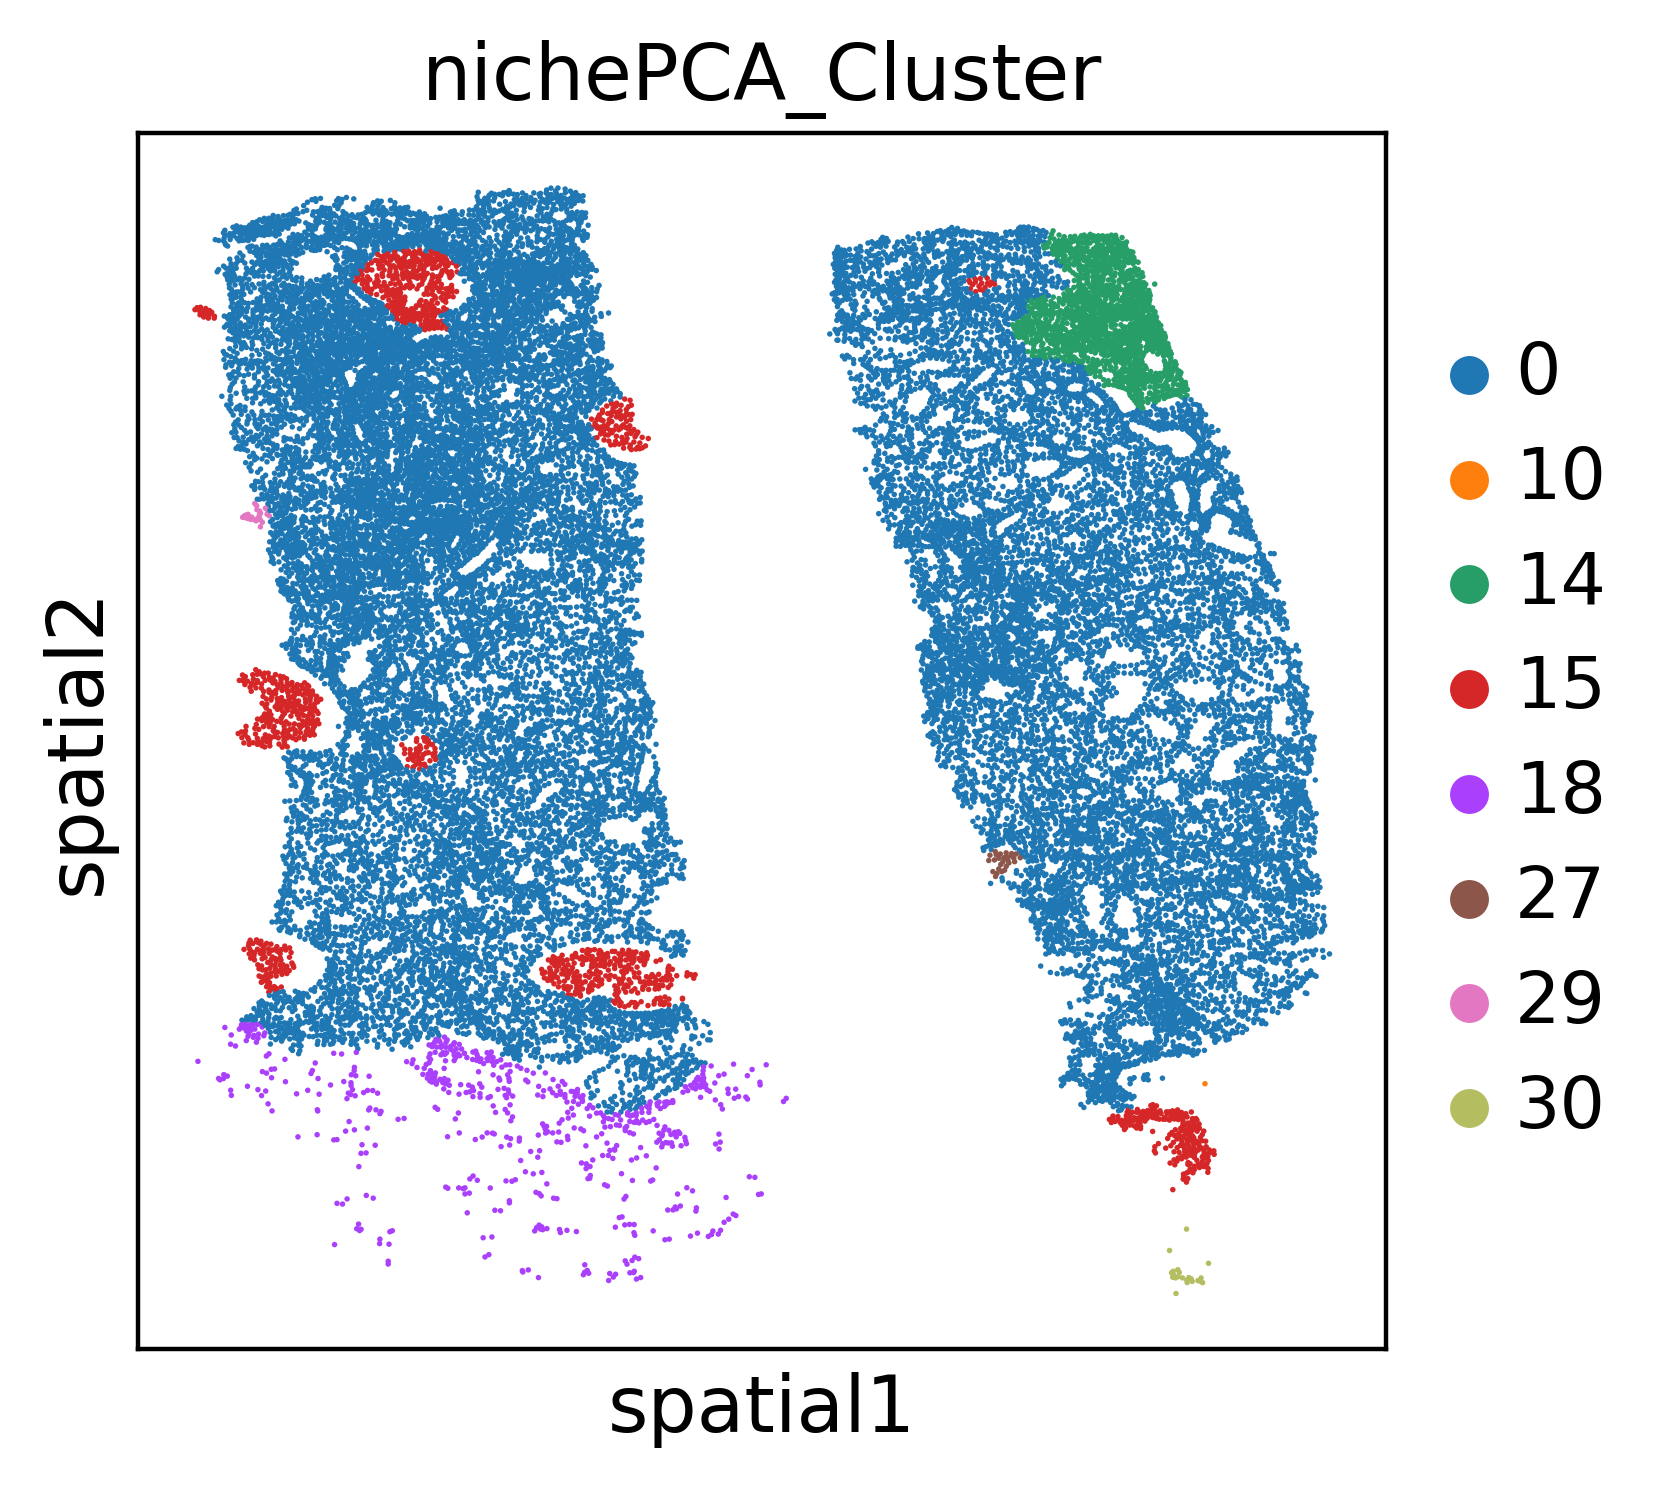

/data/projects/robin/xenium_multiview/xenium_cgn_1/lib/python3.11/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


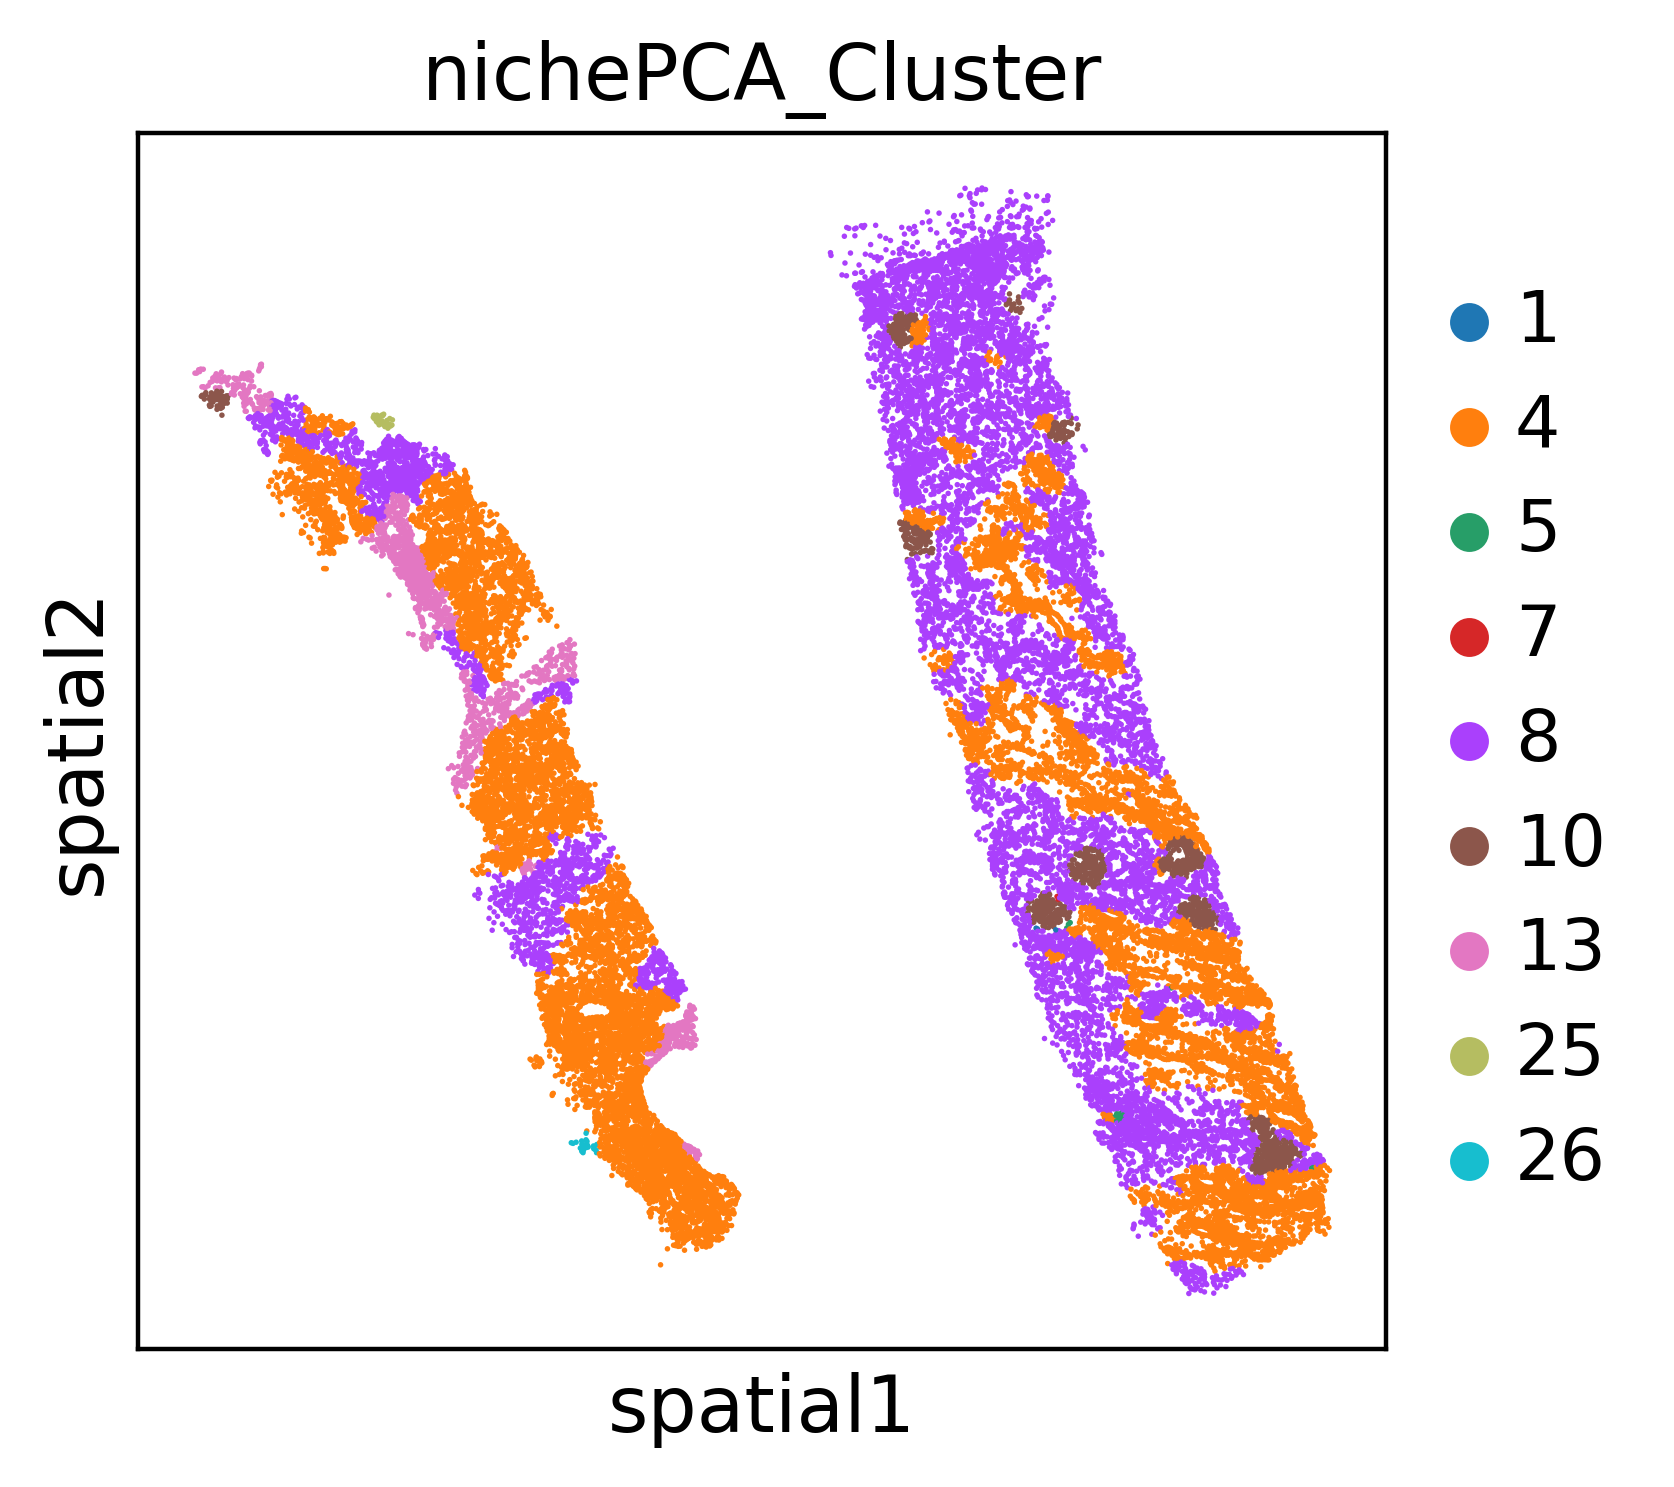

/data/projects/robin/xenium_multiview/xenium_cgn_1/lib/python3.11/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


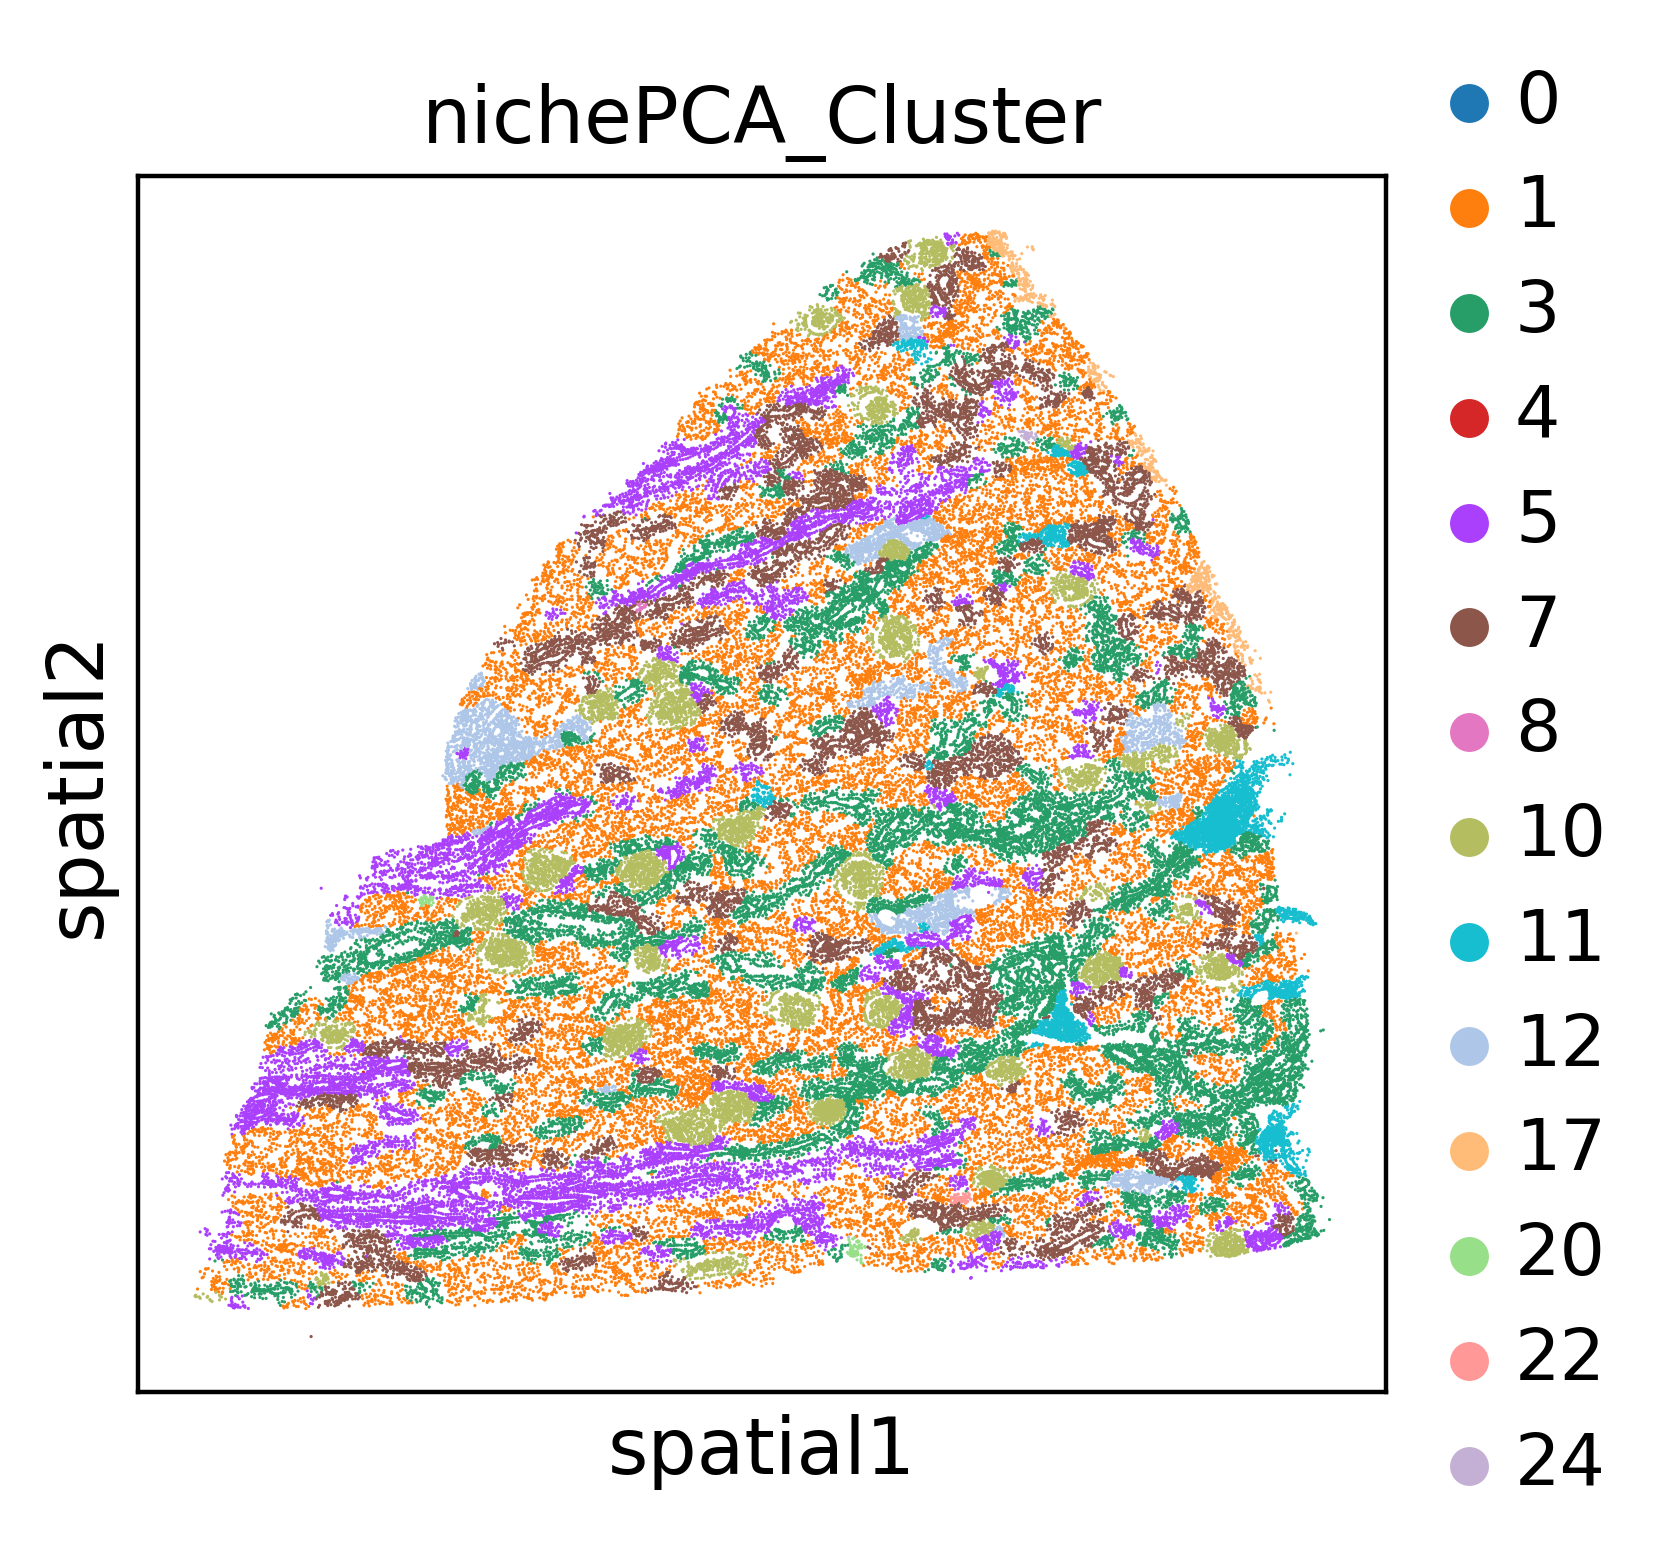

In [30]:
## Visualize clusters spatially

sc.set_figure_params(dpi=200) #  for better resolution
for donor in data.obs["Donor"].unique():
    sub = data[data.obs["Donor"]==donor]
    ax=sc.pl.embedding(sub, basis="spatial", color="nichePCA_cluster", title="nichePCA_Cluster",
                      show=False)
    ax.invert_yaxis()
    plt.show()
sc.set_figure_params(dpi=100) # reset to 100

<u>Tasks:</u>

1. plot cell type abundances for each nichePCA cluster. Cell type labels for this data are available in /home/shared/cell_types_xenium_4donors.csv. (Note: this is also done in the next notebook.)
2. Repeat the Leiden clustering across multiple resolutions and select optimal ones, based on some metric like silhoutte socre or based on better separation of marker genes. Kidney marker genes are in /home/shared/spatial-workshop-GCB-2025/kidney_markers.json. Note several markers may be absent due to Xenium data here consisting of only 480 genes.
3. Re-run nichePCA on cell type labels instead of gene expression (setting "obs_key" to cell type column in wf.nichepca). In this case, nichePCA will compute cell type abundances for computing embeddings. The idea is similar to MENDER. Cell type labels for this data are available at /home/shared/cell_types_xenium_4donors.csv.
4.  Run MENDER on the same data
5. Compare qualitatively and/or quantitattively MENDER and nichePCA in detecting glomeruli. Curated Glomeruli annotations are in /home/shared/spatial-workshop-GCB-2025/xenium_4donors_glom.csv. Glomeruli are parts of nephron with following cell types: Podocytes, endothelial, mesangial cells, pericytes and perietal epithelial cells. Out of these, podocytes and perietal epithelial cells only exist in glomeruli. 
6. There is another data at /home/shared/spatial-workshop-GCB-2025/xenium_8donors.h5ad which includes 2 more conditions: SLE and GBM. SLE: Systemic lupus erythematosus  and GBM is shorthand for anti-GBM: anti-glomerular basement syndrome (Goodpasture syndrome). Rerun nichePCA on this data and find domains of interest in studying differences between the diseases. 